# Result 06 — Research attention, national income, and biodiversity hotspots

**Status:** descriptive exploratory supporting analysis.

**Question:** how does country-level research attention differ descriptively between countries that overlap at least one of Conservation International/CEPF's 36 biodiversity hotspots and countries that do not?

The analysis reuses Result 05's exact **213 observed-country**, publication-fractional attention distribution. It builds binary and graded hotspot exposure from `checklists/mappings/biodiversity_hotspots.json`, audits country names in both directions, and treats non-hotspot status as a genuine zero after reconciliation. The analysis is descriptive throughout: the primary output is one two-group box plot, while World Bank income groups provide qualitative context only.

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_helpers import results_config, visualization

visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
GEO_CONFIG = RESULTS_CONFIG["geography_attention"]
INCOME_CONFIG = RESULTS_CONFIG["world_bank_income"]
HOTSPOT_CONFIG = RESULTS_CONFIG["research_capacity_hotspots"]
INCOME_GROUPS = INCOME_CONFIG["group_order"]
INCOME_GROUP_ADJECTIVES = {
    "Low income": "low-income",
    "Lower middle income": "lower-middle-income",
    "Upper middle income": "upper-middle-income",
    "High income": "high-income",
}

ATTENTION_PATH = (
    PROJECT_ROOT / GEO_CONFIG["output_directory"]
    / GEO_CONFIG["table_subdirectory"] / GEO_CONFIG["country_attention_file"]
)
WORLD_BANK_DIR = PROJECT_ROOT / INCOME_CONFIG["world_bank_snapshot_curated"]
WORLD_BANK_CROSSWALK_PATH = WORLD_BANK_DIR / HOTSPOT_CONFIG["world_bank_crosswalk_file"]
WORLD_BANK_CLASSIFICATION_PATH = (
    WORLD_BANK_DIR / HOTSPOT_CONFIG["world_bank_current_classification_file"]
)
HOTSPOT_PATH = PROJECT_ROOT / HOTSPOT_CONFIG["hotspot_mapping"]
OUTPUT_DIR = PROJECT_ROOT / HOTSPOT_CONFIG["output_directory"]
TABLE_DIR = OUTPUT_DIR / HOTSPOT_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / HOTSPOT_CONFIG["figure_subdirectory"]
for directory in (TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Inputs")
for label, path in (
    ("Result 05 country attention", ATTENTION_PATH),
    ("IPBES–World Bank crosswalk", WORLD_BANK_CROSSWALK_PATH),
    ("current World Bank classification", WORLD_BANK_CLASSIFICATION_PATH),
    ("biodiversity hotspot mapping", HOTSPOT_PATH),
):
    print(f"  {label}: {path.relative_to(PROJECT_ROOT)}  [{'found' if path.exists() else 'MISSING'}]")
missing = [
    path for path in (
        ATTENTION_PATH, WORLD_BANK_CROSSWALK_PATH,
        WORLD_BANK_CLASSIFICATION_PATH, HOTSPOT_PATH,
    ) if not path.exists()
]
if missing:
    raise FileNotFoundError(
        "Run the World Bank preparation and Results 02 and 05 first; missing: "
        f"{[str(path.relative_to(PROJECT_ROOT)) for path in missing]}"
    )
print(f"\nOutput section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Inputs
  Result 05 country attention: notebooks/results/outputs/05_geography_attention/csv/country_attention.csv  [found]
  IPBES–World Bank crosswalk: data/world-bank/snapshots/wdi-2026-06-30/curated/ipbes_world_bank_crosswalk.parquet  [found]
  current World Bank classification: data/world-bank/snapshots/wdi-2026-06-30/curated/classifications_current.parquet  [found]
  biodiversity hotspot mapping: checklists/mappings/biodiversity_hotspots.json  [found]

Output section: notebooks/results/outputs/06_research_capacity_and_hotspots


## 1. Reuse the 213-country attention universe and attach income group

Result 05's `attention_share_pct` is the publication-fractional percentage of the 146,631-publication base: a paper naming *k* countries contributes `1/k` to each. Only its 213 valid-ISO3 countries with observed attention enter this analysis.

Result 02 assigns **historical** income at publication × country grain, so a country may change groups over 2000–2025. A country-level descriptive grouping nevertheless requires exactly one group per country. Following Result 02's linkage workflow, each Result 05 ISO3 is joined first to the curated IPBES–World Bank crosswalk and then to the snapshot's current World Bank classification. The export retains World Bank entity code, name, region, classification year, reference year, effective dates, and a country-API URL for every country. The four income labels and order are the same ones used in Result 02 and are used only for qualitative context.

In [3]:
attention_all = pd.read_csv(ATTENTION_PATH)
attention = (
    attention_all.loc[
        attention_all["key_status"].eq("valid_iso3")
        & attention_all["evidence_status"].eq("observed"),
        [
            "country", "iso3", "region", "subregion",
            "whole_publications", "fractional_publication_equivalent",
            "attention_share_pct",
        ],
    ]
    .rename(columns={"attention_share_pct": "research_attention_pct"})
    .copy()
)
assert len(attention) == 213
assert attention["country"].is_unique and attention["iso3"].is_unique
assert np.isclose(attention["research_attention_pct"].sum(), 100.0)

world_bank_crosswalk = pd.read_parquet(
    WORLD_BANK_CROSSWALK_PATH,
    columns=[
        "ipbes_iso3", "wb_entity_code", "wb_entity_name",
        "wb_region", "has_world_bank_economy",
    ],
)
world_bank_crosswalk = world_bank_crosswalk.loc[
    world_bank_crosswalk["ipbes_iso3"].isin(attention["iso3"])
].copy()
assert world_bank_crosswalk["ipbes_iso3"].is_unique

current_classification = pd.read_parquet(
    WORLD_BANK_CLASSIFICATION_PATH,
    columns=[
        "wb_entity_code", "income_group", "classification_fy",
        "gni_reference_year", "effective_from", "effective_to",
        "is_aggregate",
    ],
).loc[lambda frame: ~frame["is_aggregate"]].drop(columns="is_aggregate")
assert current_classification["wb_entity_code"].is_unique

world_bank_linkage = (
    attention[["country", "iso3"]]
    .merge(
        world_bank_crosswalk, left_on="iso3", right_on="ipbes_iso3",
        how="left", validate="one_to_one",
    )
    .merge(current_classification, on="wb_entity_code", how="left", validate="one_to_one")
    .drop(columns="ipbes_iso3")
    .rename(columns={"income_group": "world_bank_income_group"})
)
world_bank_linkage["wb_region"] = world_bank_linkage["wb_region"].str.strip()
world_bank_linkage["world_bank_api_url"] = (
    "https://api.worldbank.org/v2/country/"
    + world_bank_linkage["wb_entity_code"] + "?format=json"
)
assert len(world_bank_linkage) == 213 and world_bank_linkage["iso3"].is_unique
assert world_bank_linkage["has_world_bank_economy"].all()
assert world_bank_linkage.drop(columns=["country", "iso3"]).notna().all().all()
assert world_bank_linkage["classification_fy"].nunique() == 1
assert set(world_bank_linkage["world_bank_income_group"]) == set(INCOME_GROUPS)

attention = attention.merge(
    world_bank_linkage, on=["country", "iso3"], how="left", validate="one_to_one"
)
assert attention["world_bank_income_group"].notna().all()
attention["world_bank_income_group"] = pd.Categorical(
    attention["world_bank_income_group"], categories=INCOME_GROUPS, ordered=True
)
print(
    f"World Bank linkage: {len(world_bank_linkage):,}/{len(attention):,} countries; "
    f"classification FY{int(world_bank_linkage['classification_fy'].iloc[0])}."
)
display(
    attention.groupby("world_bank_income_group", observed=True)
    .size().rename("countries").to_frame().style.format("{:,}")
)

World Bank linkage: 213/213 countries; classification FY2027.


,countries
world_bank_income_group,
Low income,25
Lower middle income,47
Upper middle income,58
High income,83


## 2. Reconcile hotspot country names in both directions

The direct pre-mapping anti-join identifies every spelling or naming difference. Manual rules are deliberately exhaustive: the rule keys must equal the full set of unmatched hotspot-source names, so source drift cannot be hidden by a broad fuzzy matcher. Twenty rules harmonize names to Result 05's canonical IPBES form.

**Territory decisions:** Réunion has no captured row in the 213-country attention universe and is folded into France, its parent country. New Caledonia is retained as a separate unit because Result 05 has an observed New Caledonia row. Puerto Rico does not occur in the supplied hotspot JSON. The reverse anti-join after reconciliation is expected to contain the non-hotspot comparison countries; it is not a matching failure.

In [4]:
with HOTSPOT_PATH.open(encoding="utf-8") as file:
    hotspot_mapping = json.load(file)
assert len(hotspot_mapping) == 36

hotspot_long = pd.DataFrame(
    [(hotspot, country) for hotspot, countries in hotspot_mapping.items() for country in countries],
    columns=["hotspot", "source_country"],
)
attention_names = set(attention["country"])
direct_unmatched = sorted(set(hotspot_long["source_country"]) - attention_names)

MANUAL_COUNTRY_MAP = {
    "Bahamas": "Bahamas (the)",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Brunei": "Brunei Darussalam",
    "Comoros": "Comoros (the)",
    "Democratic Republic of the Congo": "Congo (the Democratic Republic of the)",
    "Dominican Republic": "Dominican Republic (the)",
    "Federated States of Micronesia": "Micronesia (Federated States of)",
    "Iran": "Iran (Islamic Republic of)",
    "Laos": "Lao People's Democratic Republic (the)",
    "Marshall Islands": "Marshall Islands (the)",
    "Palestine": "Palestine, State of",
    "Philippines": "Philippines (the)",
    "Russia": "Russian Federation (the)",
    "Réunion (France)": "France",
    "Sudan": "Sudan (the)",
    "Syria": "Syrian Arab Republic (the)",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "Tanzania": "Tanzania, the United Republic of",
    "United States": "United States of America (the)",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "Vietnam": "Viet Nam",
}
assert set(MANUAL_COUNTRY_MAP) == set(direct_unmatched)
hotspot_long["country"] = hotspot_long["source_country"].replace(MANUAL_COUNTRY_MAP)
post_mapping_unmatched = sorted(set(hotspot_long["country"]) - attention_names)
assert not post_mapping_unmatched

mapped_hotspot_names = set(hotspot_long["country"])
attention_without_hotspot = attention.loc[
    ~attention["country"].isin(mapped_hotspot_names), ["country", "iso3"]
].sort_values("country").reset_index(drop=True)

source_name_audit = (
    hotspot_long[["source_country", "country"]].drop_duplicates()
    .rename(columns={"country": "mapped_country"})
    .sort_values("source_country").reset_index(drop=True)
)
source_name_audit["direction"] = "hotspot_to_attention"
source_name_audit["manual_rule_used"] = source_name_audit["source_country"].isin(MANUAL_COUNTRY_MAP)
source_name_audit["matched"] = source_name_audit["mapped_country"].isin(attention_names)
source_name_audit["interpretation"] = np.where(
    source_name_audit["source_country"].eq("Réunion (France)"),
    "folded into parent country",
    np.where(source_name_audit["manual_rule_used"], "canonical name harmonization", "direct exact match"),
)

reverse_name_audit = attention[["country"]].rename(columns={"country": "source_country"})
reverse_name_audit["mapped_country"] = reverse_name_audit["source_country"]
reverse_name_audit["direction"] = "attention_to_hotspot"
reverse_name_audit["manual_rule_used"] = False
reverse_name_audit["matched"] = reverse_name_audit["mapped_country"].isin(mapped_hotspot_names)
reverse_name_audit["interpretation"] = np.where(
    reverse_name_audit["matched"], "hotspot country", "expected non-hotspot comparison country"
)
name_match_audit = pd.concat([source_name_audit, reverse_name_audit], ignore_index=True)

reconciliation_summary = pd.DataFrame([
    {"stage": "before manual mapping", "direction": "hotspot_to_attention", "unmatched_countries": len(direct_unmatched), "interpretation": "requires explicit rule"},
    {"stage": "after manual mapping", "direction": "hotspot_to_attention", "unmatched_countries": len(post_mapping_unmatched), "interpretation": "must be zero"},
    {"stage": "after manual mapping", "direction": "attention_to_hotspot", "unmatched_countries": len(attention_without_hotspot), "interpretation": "expected non-hotspot comparison group"},
])
display(reconciliation_summary.style.hide(axis="index"))
display(
    source_name_audit.loc[source_name_audit["manual_rule_used"]]
    .style.hide(axis="index")
)

stage,direction,unmatched_countries,interpretation
before manual mapping,hotspot_to_attention,21,requires explicit rule
after manual mapping,hotspot_to_attention,0,must be zero
after manual mapping,attention_to_hotspot,78,expected non-hotspot comparison group


source_country,mapped_country,direction,manual_rule_used,matched,interpretation
Bahamas,Bahamas (the),hotspot_to_attention,True,True,canonical name harmonization
Bolivia,Bolivia (Plurinational State of),hotspot_to_attention,True,True,canonical name harmonization
Brunei,Brunei Darussalam,hotspot_to_attention,True,True,canonical name harmonization
Comoros,Comoros (the),hotspot_to_attention,True,True,canonical name harmonization
Democratic Republic of the Congo,Congo (the Democratic Republic of the),hotspot_to_attention,True,True,canonical name harmonization
Dominican Republic,Dominican Republic (the),hotspot_to_attention,True,True,canonical name harmonization
Federated States of Micronesia,Micronesia (Federated States of),hotspot_to_attention,True,True,canonical name harmonization
Iran,Iran (Islamic Republic of),hotspot_to_attention,True,True,canonical name harmonization
Laos,Lao People's Democratic Republic (the),hotspot_to_attention,True,True,canonical name harmonization
Marshall Islands,Marshall Islands (the),hotspot_to_attention,True,True,canonical name harmonization


## 3. Build binary and graded hotspot exposure

Collapse the reconciled long mapping to one row per represented attention country. `n_hotspots` counts distinct hotspot names; `hotspots` records the sorted names. The left join then explicitly assigns `is_hotspot_country = 0` and `n_hotspots = 0` to every attention country absent from the hotspot table.

In [5]:
hotspot_exposure = (
    hotspot_long.groupby("country", as_index=False)
    .agg(
        n_hotspots=("hotspot", "nunique"),
        hotspots=("hotspot", lambda values: "; ".join(sorted(set(values)))),
    )
)
hotspot_exposure.insert(1, "is_hotspot_country", 1)
hotspot_exposure = hotspot_exposure.sort_values("country").reset_index(drop=True)

analysis_df = attention.merge(
    hotspot_exposure, on="country", how="left", validate="one_to_one"
)
analysis_df["is_hotspot_country"] = analysis_df["is_hotspot_country"].fillna(0).astype(int)
analysis_df["n_hotspots"] = analysis_df["n_hotspots"].fillna(0).astype(int)
analysis_df["hotspots"] = analysis_df["hotspots"].fillna("")
analysis_df = analysis_df.sort_values("country").reset_index(drop=True)

assert len(hotspot_exposure) == 135
assert len(analysis_df) == 213 and analysis_df["country"].is_unique
assert analysis_df["is_hotspot_country"].sum() == 135
assert (analysis_df.loc[analysis_df["is_hotspot_country"].eq(0), "n_hotspots"] == 0).all()
assert analysis_df["n_hotspots"].between(0, 4).all()
assert np.isclose(analysis_df["research_attention_pct"].sum(), 100.0)

## 4. Descriptive categorical summary

Country attention is strongly right-skewed, so the prose leads with the median and retains the mean for the visualization. Both values are country-level shares of total publication-fractional attention.

In [6]:
def group_descriptives(frame, indicator):
    values = frame.loc[frame["is_hotspot_country"].eq(indicator), "research_attention_pct"]
    return {
        "is_hotspot_country": indicator,
        "group": "Hotspot" if indicator else "Non-hotspot",
        "n_countries": len(values),
        "mean_research_attention_pct": values.mean(),
        "median_research_attention_pct": values.median(),
        "total_research_attention_pct": values.sum(),
    }

descriptive_summary = pd.DataFrame([
    group_descriptives(analysis_df, 1), group_descriptives(analysis_df, 0)
])
display(
    descriptive_summary.style.format({
        "n_countries": "{:,}",
        "mean_research_attention_pct": "{:.3f}%",
        "median_research_attention_pct": "{:.3f}%",
        "total_research_attention_pct": "{:.3f}%",
    }).hide(axis="index")
)
hotspot_row = descriptive_summary.set_index("is_hotspot_country").loc[1]
non_hotspot_row = descriptive_summary.set_index("is_hotspot_country").loc[0]
categorical_sentence = (
    f"Hotspot countries accounted for a median of "
    f"{hotspot_row['median_research_attention_pct']:.3f}% of research attention "
    f"(mean {hotspot_row['mean_research_attention_pct']:.3f}%; "
    f"n={int(hotspot_row['n_countries'])}), compared with "
    f"{non_hotspot_row['median_research_attention_pct']:.3f}% "
    f"(mean {non_hotspot_row['mean_research_attention_pct']:.3f}%; "
    f"n={int(non_hotspot_row['n_countries'])}) for non-hotspot countries."
)
print(categorical_sentence)

is_hotspot_country,group,n_countries,mean_research_attention_pct,median_research_attention_pct,total_research_attention_pct
1,Hotspot,135,0.604%,0.076%,81.548%
0,Non-hotspot,78,0.237%,0.041%,18.452%


Hotspot countries accounted for a median of 0.076% of research attention (mean 0.604%; n=135), compared with 0.041% (mean 0.237%; n=78) for non-hotspot countries.


## 5. Qualitative income-group context

Summarize medians and means within each current World Bank income group for qualitative context only. No additional World Bank indicator is introduced. The primary figure remains the single unfaceted two-group box plot.

In [7]:
income_rows = []
for income_group in INCOME_GROUPS:
    subset = analysis_df.loc[analysis_df["world_bank_income_group"].eq(income_group)]
    hotspot_group = subset.loc[subset["is_hotspot_country"].eq(1), "research_attention_pct"]
    non_hotspot_group = subset.loc[subset["is_hotspot_country"].eq(0), "research_attention_pct"]
    income_rows.append({
        "world_bank_income_group": income_group,
        "n_hotspot": len(hotspot_group),
        "n_non_hotspot": len(non_hotspot_group),
        "median_hotspot_attention_pct": hotspot_group.median(),
        "median_non_hotspot_attention_pct": non_hotspot_group.median(),
        "mean_hotspot_attention_pct": hotspot_group.mean(),
        "mean_non_hotspot_attention_pct": non_hotspot_group.mean(),
    })
income_descriptive_summary = pd.DataFrame(income_rows)
income_descriptive_summary["median_difference_hotspot_minus_non_hotspot_pct"] = (
    income_descriptive_summary["median_hotspot_attention_pct"]
    - income_descriptive_summary["median_non_hotspot_attention_pct"]
)
display(
    income_descriptive_summary.style.format({
        "n_hotspot": "{:,}", "n_non_hotspot": "{:,}",
        "median_hotspot_attention_pct": "{:.3f}%",
        "median_non_hotspot_attention_pct": "{:.3f}%",
        "mean_hotspot_attention_pct": "{:.3f}%",
        "mean_non_hotspot_attention_pct": "{:.3f}%",
        "median_difference_hotspot_minus_non_hotspot_pct": "{:+.3f} pp",
    }).hide(axis="index")
)
median_higher_in_all_groups = bool(
    income_descriptive_summary["median_difference_hotspot_minus_non_hotspot_pct"].gt(0).all()
)
largest_income_contrast = income_descriptive_summary.loc[
    income_descriptive_summary["median_difference_hotspot_minus_non_hotspot_pct"].idxmax(),
    "world_bank_income_group",
]
assert median_higher_in_all_groups
income_sentence = (
    "The same descriptive pattern was visible within all four World Bank income groups, "
    f"with the largest median contrast among {INCOME_GROUP_ADJECTIVES[largest_income_contrast]} countries."
)
print(income_sentence)

world_bank_income_group,n_hotspot,n_non_hotspot,median_hotspot_attention_pct,median_non_hotspot_attention_pct,mean_hotspot_attention_pct,mean_non_hotspot_attention_pct,median_difference_hotspot_minus_non_hotspot_pct
Low income,16,9,0.040%,0.027%,0.123%,0.057%,+0.013 pp
Lower middle income,40,7,0.097%,0.030%,0.279%,0.133%,+0.068 pp
Upper middle income,49,9,0.059%,0.040%,0.675%,0.101%,+0.019 pp
High income,30,53,0.168%,0.096%,1.178%,0.304%,+0.072 pp


The same descriptive pattern was visible within all four World Bank income groups, with the largest median contrast among high-income countries.


## 6. Primary visualization

The primary figure compares the complete hotspot and non-hotspot distributions. A second, 2 × 2 faceted version repeats the same comparison within each current World Bank income group as descriptive research-capacity context. Boxes show the interquartile range, the central line is the median, whiskers extend to 1.5 times the interquartile range, points are observations beyond the whiskers, and diamonds mark arithmetic means. Because positive country shares span several orders of magnitude, both figures use a logarithmic vertical display scale; all summaries are calculated on the original percentage values.

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/06_research_capacity_and_hotspots/figures/hotspot_attention_boxplot.pdf


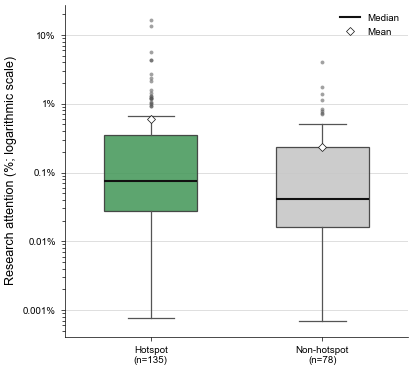

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/06_research_capacity_and_hotspots/figures/hotspot_attention_boxplot_by_income_group.pdf


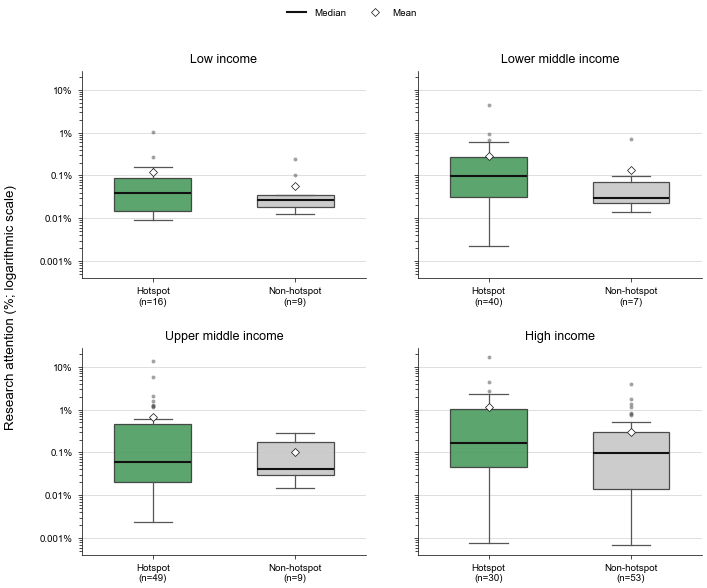

In [8]:
hotspot_values = analysis_df.loc[
    analysis_df["is_hotspot_country"].eq(1), "research_attention_pct"
]
non_hotspot_values = analysis_df.loc[
    analysis_df["is_hotspot_country"].eq(0), "research_attention_pct"
]
assert hotspot_values.gt(0).all() and non_hotspot_values.gt(0).all()

figure, axis = plt.subplots(figsize=(4.4, 4.2))
boxplot = axis.boxplot(
    [hotspot_values, non_hotspot_values],
    positions=[1, 2],
    widths=0.54,
    patch_artist=True,
    showmeans=True,
    whis=1.5,
    tick_labels=[f"Hotspot\n(n={len(hotspot_values)})", f"Non-hotspot\n(n={len(non_hotspot_values)})"],
    boxprops={"linewidth": 0.9, "edgecolor": "#3A3A3A"},
    medianprops={"color": "#111111", "linewidth": 1.5},
    whiskerprops={"color": "#555555", "linewidth": 0.9},
    capprops={"color": "#555555", "linewidth": 0.9},
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "#111111", "markersize": 4.5},
    flierprops={"marker": "o", "markerfacecolor": "#555555", "markeredgecolor": "none", "markersize": 2.8, "alpha": 0.55},
)
for patch, color in zip(boxplot["boxes"], ["#4B9B5F", "#C7C7C7"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)

axis.set_yscale("log")
axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}%"))
axis.set_ylabel("Research attention (%; logarithmic scale)")
axis.grid(axis="y", which="major", color="#D9D9D9", linewidth=0.6)
axis.set_axisbelow(True)
axis.legend(
    handles=[
        Line2D([0], [0], color="#111111", linewidth=1.5, label="Median"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="white", markeredgecolor="#111111", markersize=4.5, label="Mean"),
    ],
    loc="upper right",
    frameon=False,
)
figure.subplots_adjust(left=0.19, right=0.97, bottom=0.17, top=0.96)
visualization.save_figure(
    figure, FIGURE_DIR / HOTSPOT_CONFIG["boxplot_figure_filename"],
    formats=["pdf"], dpi=300, pad_inches=0.04,
)
plt.show()

income_figure, income_axes = plt.subplots(2, 2, figsize=(7.3, 6.2), sharey=True)
for income_group, panel_axis in zip(INCOME_GROUPS, np.asarray(income_axes).ravel()):
    income_subset = analysis_df.loc[
        analysis_df["world_bank_income_group"].eq(income_group)
    ]
    income_hotspot = income_subset.loc[
        income_subset["is_hotspot_country"].eq(1), "research_attention_pct"
    ]
    income_non_hotspot = income_subset.loc[
        income_subset["is_hotspot_country"].eq(0), "research_attention_pct"
    ]
    panel_boxplot = panel_axis.boxplot(
        [income_hotspot, income_non_hotspot],
        positions=[1, 2],
        widths=0.54,
        patch_artist=True,
        showmeans=True,
        whis=1.5,
        tick_labels=[
            f"Hotspot\n(n={len(income_hotspot)})",
            f"Non-hotspot\n(n={len(income_non_hotspot)})",
        ],
        boxprops={"linewidth": 0.9, "edgecolor": "#3A3A3A"},
        medianprops={"color": "#111111", "linewidth": 1.5},
        whiskerprops={"color": "#555555", "linewidth": 0.9},
        capprops={"color": "#555555", "linewidth": 0.9},
        meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "#111111", "markersize": 4.5},
        flierprops={"marker": "o", "markerfacecolor": "#555555", "markeredgecolor": "none", "markersize": 2.8, "alpha": 0.55},
    )
    for patch, color in zip(panel_boxplot["boxes"], ["#4B9B5F", "#C7C7C7"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)
    panel_axis.set_yscale("log")
    panel_axis.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}%"))
    panel_axis.set_title(income_group)
    panel_axis.grid(axis="y", which="major", color="#D9D9D9", linewidth=0.6)
    panel_axis.set_axisbelow(True)

income_figure.supylabel("Research attention (%; logarithmic scale)", x=0.025)
income_figure.legend(
    handles=[
        Line2D([0], [0], color="#111111", linewidth=1.5, label="Median"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="white", markeredgecolor="#111111", markersize=4.5, label="Mean"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=2,
    frameon=False,
)
income_figure.subplots_adjust(left=0.13, right=0.98, bottom=0.10, top=0.88, wspace=0.18, hspace=0.34)
visualization.save_figure(
    income_figure, FIGURE_DIR / HOTSPOT_CONFIG["income_boxplot_figure_filename"],
    formats=["pdf"], dpi=300, pad_inches=0.04,
)
plt.show()

## 7. Discussion-ready descriptive result

The generated paragraph below follows the requested number-first format and uses association language only.

In [9]:
discussion_paragraph = f"{categorical_sentence} {income_sentence}"
print(discussion_paragraph)

Hotspot countries accounted for a median of 0.076% of research attention (mean 0.604%; n=135), compared with 0.041% (mean 0.237%; n=78) for non-hotspot countries. The same descriptive pattern was visible within all four World Bank income groups, with the largest median contrast among high-income countries.


### Caveats to carry into the write-up

- Hotspot membership records country presence/absence within a biogeographic boundary; it is not weighted by the fraction of national territory inside that boundary.
- `n_hotspots` remains available in the source and merged tables but is not used in this simplified categorical analysis.
- Réunion is folded into France, which assigns France both the Mediterranean Basin and Madagascar/Indian Ocean Islands memberships. New Caledonia remains separate.
- Income group is a current country-level descriptor linked through the same curated World Bank sources that feed Result 02; it is not Result 02's publication-year-specific historical exposure.
- Country attention shares are compositional and right-skewed. Results describe association in this coded evidence base, not where biodiversity loss occurs or why research is allocated.

## 8. Export analysis tables and provenance

The hotspot-only table has the requested categorical/graded schema. The full 213-country table carries the zeros used in analysis, and a separate 213-row linkage table records each attention country's World Bank entity and current classification. Name audits preserve all 136 source names and all 213 reverse checks.

In [10]:
discussion_summary = pd.DataFrame([{
    "categorical_sentence": categorical_sentence,
    "income_context_sentence": income_sentence,
    "discussion_paragraph": discussion_paragraph,
}])

table_outputs = {
    HOTSPOT_CONFIG["hotspot_exposure_file"]: hotspot_exposure[
        ["country", "is_hotspot_country", "n_hotspots", "hotspots"]
    ],
    HOTSPOT_CONFIG["world_bank_linkage_file"]: world_bank_linkage,
    HOTSPOT_CONFIG["analysis_file"]: analysis_df[
        [
            "country", "iso3", "region", "subregion",
            "wb_entity_code", "wb_entity_name", "wb_region",
            "world_bank_income_group", "classification_fy",
            "gni_reference_year", "effective_from", "effective_to",
            "world_bank_api_url",
            "whole_publications", "fractional_publication_equivalent",
            "research_attention_pct",
            "is_hotspot_country", "n_hotspots", "hotspots",
        ]
    ],
    HOTSPOT_CONFIG["name_match_audit_file"]: name_match_audit,
    HOTSPOT_CONFIG["name_reconciliation_summary_file"]: reconciliation_summary,
    HOTSPOT_CONFIG["descriptive_summary_file"]: descriptive_summary,
    HOTSPOT_CONFIG["income_descriptive_summary_file"]: income_descriptive_summary,
    HOTSPOT_CONFIG["discussion_file"]: discussion_summary,
}
table_paths = []
for filename, frame in table_outputs.items():
    path = TABLE_DIR / filename
    frame.to_csv(path, index=False)
    table_paths.append(path)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

figure_paths = sorted(FIGURE_DIR.glob("*.pdf"))
assert {path.stem for path in figure_paths} == {
    HOTSPOT_CONFIG["boxplot_figure_filename"],
    HOTSPOT_CONFIG["income_boxplot_figure_filename"],
}

manifest = {
    "result": "06_research_capacity_and_hotspots",
    "status": "descriptive_exploratory_supporting_analysis",
    "analysis_parameters": {
        "country_universe": "213 observed valid-ISO3 countries exported by Result 05",
        "research_attention_measure": "publication-fractional attention share percent",
        "analysis_scope": "descriptive summaries and visualization only",
        "income_group_role": "qualitative descriptive context only",
        "graded_hotspot_count_used": False,
        "primary_figure": "pooled two-group box plot on logarithmic display scale",
        "income_context_figure": "2x2 box-plot facets by current World Bank income group",
        "world_bank_classification_fy": int(world_bank_linkage["classification_fy"].iloc[0]),
        "hotspot_source_count": len(hotspot_mapping),
        "territory_rule_reunion": "fold into France",
        "territory_rule_new_caledonia": "retain as separate observed attention unit",
    },
    "inputs": {
        "result05_country_attention": str(ATTENTION_PATH.relative_to(PROJECT_ROOT)),
        "result05_country_attention_sha256": sha256(ATTENTION_PATH),
        "world_bank_country_crosswalk": str(WORLD_BANK_CROSSWALK_PATH.relative_to(PROJECT_ROOT)),
        "world_bank_country_crosswalk_sha256": sha256(WORLD_BANK_CROSSWALK_PATH),
        "world_bank_current_classification": str(WORLD_BANK_CLASSIFICATION_PATH.relative_to(PROJECT_ROOT)),
        "world_bank_current_classification_sha256": sha256(WORLD_BANK_CLASSIFICATION_PATH),
        "biodiversity_hotspot_mapping": str(HOTSPOT_PATH.relative_to(PROJECT_ROOT)),
        "biodiversity_hotspot_mapping_sha256": sha256(HOTSPOT_PATH),
    },
    "reconciliation": {
        "source_hotspots": len(hotspot_mapping),
        "source_country_names": int(hotspot_long["source_country"].nunique()),
        "manual_name_rules": len(MANUAL_COUNTRY_MAP),
        "post_mapping_unmatched_source_names": len(post_mapping_unmatched),
        "represented_hotspot_countries_after_territory_rule": len(hotspot_exposure),
        "non_hotspot_attention_countries": len(attention_without_hotspot),
        "countries_linked_to_world_bank": len(world_bank_linkage),
    },
    "artifacts": [str(path.relative_to(OUTPUT_DIR)) for path in [*table_paths, *figure_paths]]
    + [HOTSPOT_CONFIG["manifest_filename"]],
}
manifest_path = OUTPUT_DIR / HOTSPOT_CONFIG["manifest_filename"]
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")

for path in [*table_paths, *figure_paths, manifest_path]:
    print(path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/06_research_capacity_and_hotspots/csv/country_hotspot_categorical_and_graded.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/csv/country_world_bank_linkage.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/csv/country_research_attention_hotspot_analysis.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/csv/country_name_match_audit.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/csv/country_name_reconciliation_summary.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/csv/hotspot_attention_descriptive_summary.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/csv/hotspot_attention_descriptive_by_income_group.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/csv/discussion_summary.csv
notebooks/results/outputs/06_research_capacity_and_hotspots/figures/hotspot_attention_boxplot.pdf
notebooks/results/outputs/06_research_capacity_and_hotspots/figures/hotspot_attentio